# 37 - Synthetic Augmentation for Privacy-Aware Training

Train VAEs on retain + synthetic rare-subtype cells instead of retain + real
rare-subtype cells. Tests whether replacing real training samples with synthetic
ones prevents memorization while preserving subtype biology.

Fisher analysis identifies where memorization concentrates (rare subpopulations
with high Fisher overlap). This experiment tests the constructive response:
augment those subpopulations to prevent memorization at training time.

**Part 1:** PBMC (30 megakaryocytes, genuine memorization exists)
**Part 2:** TCGA-BRCA (158 Basal patients, no patient-level memorization detected)

**Source functions:** `src/augmentation_utils.py`

**Dependencies:** `data/adata_processed.h5ad`, `data/tcga_brca/tcga_brca_processed.h5ad`, baseline/retrain checkpoints

In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import torch
import json
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc
from pathlib import Path
from sklearn.decomposition import PCA

from utils import set_global_seed, GLOBAL_SEED, DEVICE
from vae import VAE, vae_loss
from attacker import extract_vae_features, build_attack_features, MLPAttacker
from attacker_eval import matched_negative_evaluation
from augmentation_utils import generate_bootstrap_augmented, train_augmented_vae
from synthetic_utils import extract_mia_features, train_and_evaluate_attacker

set_global_seed(GLOBAL_SEED)
plt.style.use('seaborn-v0_8-whitegrid')

OUTPUT_DIR = Path('../outputs/augmentation')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

## Part 1: PBMC-33k (megakaryocytes)

In [2]:
adata_pbmc = sc.read_h5ad('../data/adata_processed.h5ad')
X_pbmc = adata_pbmc.X.toarray() if hasattr(adata_pbmc.X, 'toarray') else adata_pbmc.X
leiden = adata_pbmc.obs['leiden'].values

with open('../outputs/p1/split_structured.json') as f:
    split_pbmc = json.load(f)

forget_idx = split_pbmc['forget_indices']
retain_idx = split_pbmc['retain_indices']
unseen_idx = split_pbmc['unseen_indices']
c13_unseen = [i for i in unseen_idx if leiden[i] == '13']

with open('../outputs/p1.5/s1_matched_negatives.json') as f:
    matched_pbmc = json.load(f)
matched_idx = matched_pbmc['matched_indices']

# Load baseline config
baseline_ckpt = torch.load('../outputs/p1/baseline/best_model.pt', map_location=DEVICE)
config_pbmc = baseline_ckpt['config']

def load_model(path):
    ckpt = torch.load(path, map_location=DEVICE)
    mc = {k: v for k, v in ckpt['config'].items()
          if k in ['input_dim', 'latent_dim', 'hidden_dims', 'likelihood', 'dropout', 'use_layer_norm']}
    model = VAE(**mc).to(DEVICE)
    model.load_state_dict(ckpt['model_state_dict'])
    model.eval()
    return model

baseline_pbmc = load_model('../outputs/p1/baseline/best_model.pt')
retrain_pbmc = load_model('../outputs/p1/retrain_structured/best_model.pt')

### Generate synthetic megakaryocytes

In [3]:
# Use ONLY the 5 unseen cluster-13 cells as seeds (not the 30 training cells)
seed_cells = X_pbmc[c13_unseen]

synth_30 = generate_bootstrap_augmented(seed_cells, n_synthetic=30, noise_scale=0.1, seed=42)
synth_100 = generate_bootstrap_augmented(seed_cells, n_synthetic=100, noise_scale=0.1, seed=42)

# Validate: sparsity and expression range
real_c13 = X_pbmc[forget_idx]
pd.DataFrame({
    'Metric': ['Samples', 'Sparsity', 'Mean (nonzero)', 'Library size (mean)'],
    'Real c13 (train)': [len(real_c13), f'{(real_c13==0).mean():.3f}',
                         f'{real_c13[real_c13>0].mean():.3f}', f'{real_c13.sum(axis=1).mean():.0f}'],
    'Seed cells (5 unseen)': [len(seed_cells), f'{(seed_cells==0).mean():.3f}',
                              f'{seed_cells[seed_cells>0].mean():.3f}', f'{seed_cells.sum(axis=1).mean():.0f}'],
    'Synthetic (30)': [len(synth_30), f'{(synth_30==0).mean():.3f}',
                       f'{synth_30[synth_30>0].mean():.3f}', f'{synth_30.sum(axis=1).mean():.0f}'],
    'Synthetic (100)': [len(synth_100), f'{(synth_100==0).mean():.3f}',
                        f'{synth_100[synth_100>0].mean():.3f}', f'{synth_100.sum(axis=1).mean():.0f}'],
}).set_index('Metric')

,Real c13 (train),Seed cells (5 unseen),Synthetic (30),Synthetic (100)
Metric,,,,
Samples,30,5,30,100
Sparsity,0.874,0.861,0.861,0.861
Mean (nonzero),1.848,1.760,1.772,1.751
Library size (mean),464,489,494,488


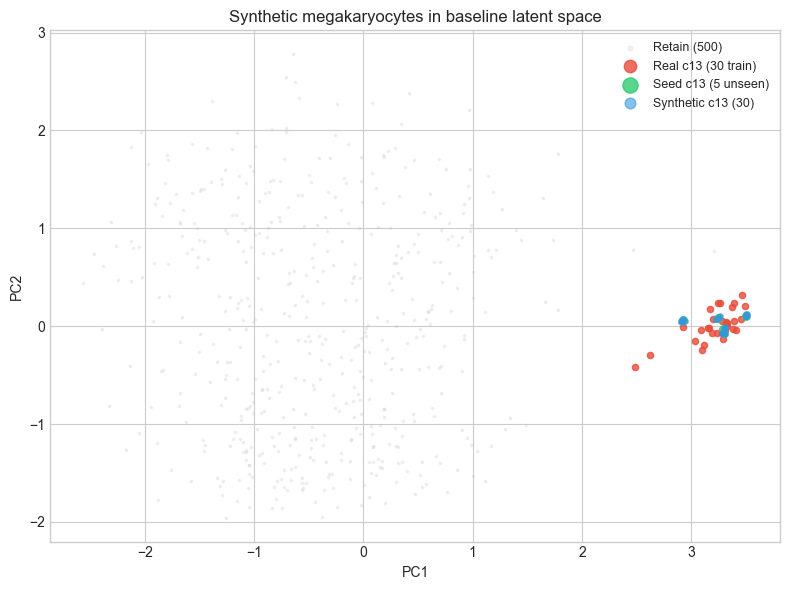

In [4]:
# Visualize in baseline latent space
with torch.no_grad():
    mu_forget, _ = baseline_pbmc.encode(torch.FloatTensor(real_c13).to(DEVICE))
    mu_seed, _ = baseline_pbmc.encode(torch.FloatTensor(seed_cells).to(DEVICE))
    mu_s30, _ = baseline_pbmc.encode(torch.FloatTensor(synth_30).to(DEVICE))
    mu_retain_sample, _ = baseline_pbmc.encode(
        torch.FloatTensor(X_pbmc[retain_idx[:500]]).to(DEVICE))

all_mu = torch.cat([mu_forget.cpu(), mu_seed.cpu(), mu_s30.cpu(), mu_retain_sample.cpu()])
pca = PCA(n_components=2)
z_pca = pca.fit_transform(all_mu.numpy())

n_f, n_s, n_s30, n_r = len(real_c13), len(seed_cells), len(synth_30), 500
splits = np.cumsum([0, n_f, n_s, n_s30, n_r])

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(z_pca[splits[3]:splits[4], 0], z_pca[splits[3]:splits[4], 1],
           s=3, alpha=0.2, c='#bdc3c7', label='Retain (500)')
ax.scatter(z_pca[splits[0]:splits[1], 0], z_pca[splits[0]:splits[1], 1],
           s=20, alpha=0.8, c='#e74c3c', label='Real c13 (30 train)')
ax.scatter(z_pca[splits[1]:splits[2], 0], z_pca[splits[1]:splits[2], 1],
           s=30, alpha=0.8, c='#2ecc71', label='Seed c13 (5 unseen)')
ax.scatter(z_pca[splits[2]:splits[3], 0], z_pca[splits[2]:splits[3], 1],
           s=15, alpha=0.6, c='#3498db', label='Synthetic c13 (30)')
ax.legend(markerscale=2, fontsize=9)
ax.set_title('Synthetic megakaryocytes in baseline latent space')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'pbmc_synthetic_validation.png', dpi=150, bbox_inches='tight')
plt.show()

### Train augmented models

In [5]:
X_retain = X_pbmc[retain_idx]

# Augmented-match: retain + 30 synthetic (same count as original forget set)
aug30_model, aug30_loss = train_augmented_vae(
    X_retain, synth_30, config_pbmc, device=DEVICE, seed=GLOBAL_SEED)
torch.save({'model_state_dict': aug30_model.state_dict(), 'config': config_pbmc,
            'train_loss': aug30_loss, 'method': 'augmented_30'},
           OUTPUT_DIR / 'pbmc_aug30_model.pt')

# Augmented-over: retain + 100 synthetic (oversampled)
aug100_model, aug100_loss = train_augmented_vae(
    X_retain, synth_100, config_pbmc, device=DEVICE, seed=GLOBAL_SEED)
torch.save({'model_state_dict': aug100_model.state_dict(), 'config': config_pbmc,
            'train_loss': aug100_loss, 'method': 'augmented_100'},
           OUTPUT_DIR / 'pbmc_aug100_model.pt')

### MIA evaluation (cross-cluster matching)

In [6]:
x_forget_t = torch.FloatTensor(real_c13)
x_matched_t = torch.FloatTensor(X_pbmc[matched_idx])

pbmc_results = {}
for name, model in [('Baseline', baseline_pbmc), ('Retrain', retrain_pbmc),
                     ('Augmented-30', aug30_model), ('Augmented-100', aug100_model)]:
    forget_feats = extract_mia_features(model, x_forget_t, device=DEVICE)
    matched_feats = extract_mia_features(model, x_matched_t, device=DEVICE)
    res = train_and_evaluate_attacker(forget_feats, matched_feats, device=DEVICE)
    pbmc_results[name] = res

In [7]:
# Within-cluster evaluation (5 real unseen c13)
x_c13_t = torch.FloatTensor(seed_cells)
pbmc_within = {}
for name, model in [('Baseline', baseline_pbmc), ('Retrain', retrain_pbmc),
                     ('Augmented-30', aug30_model), ('Augmented-100', aug100_model)]:
    forget_feats = extract_mia_features(model, x_forget_t, device=DEVICE)
    within_feats = extract_mia_features(model, x_c13_t, device=DEVICE)
    res = train_and_evaluate_attacker(forget_feats, within_feats, device=DEVICE)
    pbmc_within[name] = res

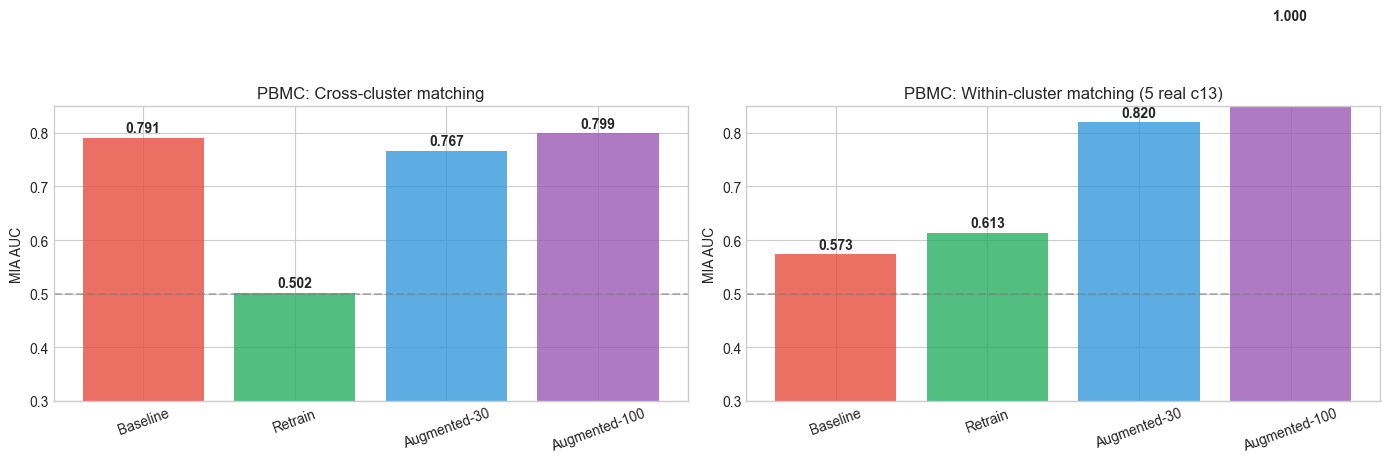

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

names = list(pbmc_results.keys())
colors = ['#e74c3c', '#27ae60', '#3498db', '#9b59b6']

# Cross-cluster
axes[0].bar(names, [pbmc_results[n]['auc'] for n in names], color=colors, alpha=0.8)
axes[0].axhline(0.5, color='gray', ls='--', alpha=0.5)
axes[0].set_ylabel('MIA AUC')
axes[0].set_title('PBMC: Cross-cluster matching')
axes[0].set_ylim(0.3, 0.85)
axes[0].tick_params(axis='x', rotation=20)
for i, n in enumerate(names):
    axes[0].text(i, pbmc_results[n]['auc'] + 0.01,
                 f'{pbmc_results[n]["auc"]:.3f}', ha='center', fontsize=10, fontweight='bold')

# Within-cluster
axes[1].bar(names, [pbmc_within[n]['auc'] for n in names], color=colors, alpha=0.8)
axes[1].axhline(0.5, color='gray', ls='--', alpha=0.5)
axes[1].set_ylabel('MIA AUC')
axes[1].set_title('PBMC: Within-cluster matching (5 real c13)')
axes[1].set_ylim(0.3, 0.85)
axes[1].tick_params(axis='x', rotation=20)
for i, n in enumerate(names):
    axes[1].text(i, pbmc_within[n]['auc'] + 0.01,
                 f'{pbmc_within[n]["auc"]:.3f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'pbmc_augmentation_results.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
df = pd.DataFrame({
    'Model': names,
    'Cross-cluster AUC': [pbmc_results[n]['auc'] for n in names],
    'Cross-cluster Advantage': [pbmc_results[n]['advantage'] for n in names],
    'Within-cluster AUC': [pbmc_within[n]['auc'] for n in names],
    'Within-cluster Advantage': [pbmc_within[n]['advantage'] for n in names],
}).set_index('Model')
df.style.format('{:.3f}')

,Cross-cluster AUC,Cross-cluster Advantage,Within-cluster AUC,Within-cluster Advantage
Model,,,,
Baseline,0.791,0.581,0.573,0.147
Retrain,0.502,0.003,0.613,0.227
Augmented-30,0.767,0.534,0.820,0.640
Augmented-100,0.799,0.599,1.000,1.000


## Part 2: TCGA-BRCA (Basal patients)

In [10]:
adata_tcga = sc.read_h5ad('../data/tcga_brca/tcga_brca_processed.h5ad')
X_tcga = adata_tcga.X if not hasattr(adata_tcga.X, 'toarray') else adata_tcga.X.toarray()
subtypes = adata_tcga.obs['subtype'].values

with open('../outputs/tcga_brca/split_structured.json') as f:
    split_tcga = json.load(f)

forget_tcga = split_tcga['forget_indices']
retain_tcga = split_tcga['retain_indices']
unseen_tcga = split_tcga['unseen_indices']
unseen_basal = [i for i in unseen_tcga if subtypes[i] == 'Basal']

tcga_ckpt = torch.load('../outputs/tcga_brca/baseline/best_model.pt', map_location=DEVICE)
config_tcga = tcga_ckpt['config']

baseline_tcga = load_model('../outputs/tcga_brca/baseline/best_model.pt')
retrain_tcga = load_model('../outputs/tcga_brca/retrain_structured/best_model.pt')

# Generate synthetic Basal from 30 unseen Basal patients
seed_basal = X_tcga[unseen_basal]
synth_basal_158 = generate_bootstrap_augmented(seed_basal, n_synthetic=158, noise_scale=0.1, seed=42)

# Train augmented model
X_retain_tcga = X_tcga[retain_tcga]
aug_tcga_model, aug_tcga_loss = train_augmented_vae(
    X_retain_tcga, synth_basal_158, config_tcga, device=DEVICE, seed=GLOBAL_SEED)
torch.save({'model_state_dict': aug_tcga_model.state_dict(), 'config': config_tcga,
            'train_loss': aug_tcga_loss, 'method': 'augmented_158'},
           OUTPUT_DIR / 'tcga_aug_model.pt')

In [11]:
# Within-subtype evaluation (unseen Basal only)
x_forget_tcga = torch.FloatTensor(X_tcga[forget_tcga])
x_unseen_basal = torch.FloatTensor(X_tcga[unseen_basal])

tcga_results = {}
for name, model in [('Baseline', baseline_tcga), ('Retrain', retrain_tcga),
                     ('Augmented-158', aug_tcga_model)]:
    forget_feats = extract_mia_features(model, x_forget_tcga, device=DEVICE)
    matched_feats = extract_mia_features(model, x_unseen_basal, device=DEVICE)
    res = train_and_evaluate_attacker(forget_feats, matched_feats, device=DEVICE)
    tcga_results[name] = res

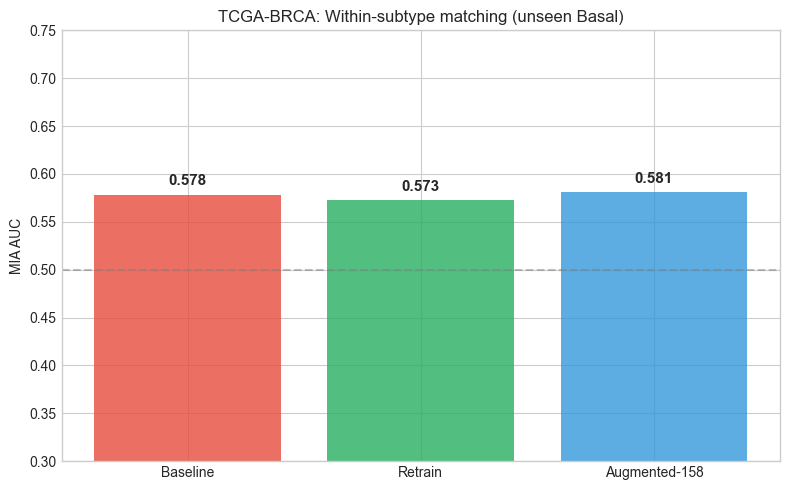

In [12]:
fig, ax = plt.subplots(figsize=(8, 5))

names_tcga = list(tcga_results.keys())
colors_tcga = ['#e74c3c', '#27ae60', '#3498db']

ax.bar(names_tcga, [tcga_results[n]['auc'] for n in names_tcga],
       color=colors_tcga, alpha=0.8)
ax.axhline(0.5, color='gray', ls='--', alpha=0.5)
ax.set_ylabel('MIA AUC')
ax.set_title('TCGA-BRCA: Within-subtype matching (unseen Basal)')
ax.set_ylim(0.3, 0.75)
for i, n in enumerate(names_tcga):
    ax.text(i, tcga_results[n]['auc'] + 0.01,
            f'{tcga_results[n]["auc"]:.3f}', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'tcga_augmentation_results.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
pd.DataFrame({
    'Model': names_tcga,
    'Within-subtype AUC': [tcga_results[n]['auc'] for n in names_tcga],
    'Advantage': [tcga_results[n]['advantage'] for n in names_tcga],
}).set_index('Model').style.format('{:.3f}')

,Within-subtype AUC,Advantage
Model,,
Baseline,0.578,0.156
Retrain,0.573,0.145
Augmented-158,0.581,0.162


## Save results

In [14]:
all_results = {
    'pbmc': {
        'cross_cluster': {n: r for n, r in pbmc_results.items()},
        'within_cluster': {n: r for n, r in pbmc_within.items()},
        'n_seed_cells': len(c13_unseen),
        'n_synthetic_30': len(synth_30),
        'n_synthetic_100': len(synth_100),
    },
    'tcga_brca': {
        'within_subtype': {n: r for n, r in tcga_results.items()},
        'n_seed_cells': len(unseen_basal),
        'n_synthetic': len(synth_basal_158),
    },
}

with open(OUTPUT_DIR / 'augmentation_results.json', 'w') as f:
    json.dump(all_results, f, indent=2)

## Summary

| Output | Path |
|--------|------|
| PBMC synthetic validation | `outputs/augmentation/pbmc_synthetic_validation.png` |
| PBMC augmentation results | `outputs/augmentation/pbmc_augmentation_results.png` |
| TCGA-BRCA augmentation results | `outputs/augmentation/tcga_augmentation_results.png` |
| PBMC augmented models | `outputs/augmentation/pbmc_aug{30,100}_model.pt` |
| TCGA-BRCA augmented model | `outputs/augmentation/tcga_aug_model.pt` |
| Results JSON | `outputs/augmentation/augmentation_results.json` |

Training on retain + synthetic rare-subtype cells tests whether memorization
can be prevented at training time while preserving subtype biology.